### Veri Analizi

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
# 1. Veri Setini Yükle
df = pd.read_csv("arabam_merged_180k.csv")
# 2. SADECE 2. EL ARAÇLARI FİLTRELE
df = df[df['arac_durumu'] == 'İkinci El'].copy()
# 3. İstediginiz Sütunların Listesi (+ Target olan 'fiyat' kolonunu unutmuyoruz)
istenen_sutunlar = [
    "ilan_tarihi",'fiyat', 'marka', 'seri', 'model', 'yil', 'km', 'vites_tipi', 'yakit_tipi',
    'kasa_tipi', 'motor_hacmi', 'motor_gucu', 'cekis', 'agir_hasarli','sag_arka_camurluk'
    ,'arka_kaput', 'sol_arka_camurluk', 
    'sag_arka_kapi', 'sag_on_kapi', 'tavan', 'sol_arka_kapi', 'sol_on_kapi', 
    'sag_on_camurluk', 'motor_kaputu', 'sol_on_camurluk', 'on_tampon', 'arka_tampon'
]
df2 = df.copy()
# Sadece bu listelediğimiz sütunları veride bırakalım
df2 = df2[istenen_sutunlar]

In [2]:
df2.shape

(180652, 27)

In [4]:
print(df2.columns.tolist())

['ilan_tarihi', 'fiyat', 'marka', 'seri', 'model', 'yil', 'km', 'vites_tipi', 'yakit_tipi', 'kasa_tipi', 'motor_hacmi', 'motor_gucu', 'cekis', 'agir_hasarli', 'sag_arka_camurluk', 'arka_kaput', 'sol_arka_camurluk', 'sag_arka_kapi', 'sag_on_kapi', 'tavan', 'sol_arka_kapi', 'sol_on_kapi', 'sag_on_camurluk', 'motor_kaputu', 'sol_on_camurluk', 'on_tampon', 'arka_tampon']


In [5]:
df2['fiyat'] = pd.to_numeric(df2['fiyat'], errors='coerce')
df2['yil'] = pd.to_numeric(df2['yil'], errors='coerce')
df2['km'] = pd.to_numeric(df2['km'], errors='coerce')

In [6]:
ay_map = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04',
    'Mayıs': '05', 'Haziran': '06', 'Temmuz': '07', 'Ağustos': '08',
    'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}

# 2. Önce metin içindeki ay isimlerini sayıya dönüştür
df2['ilan_tarihi'] = df2['ilan_tarihi'].replace(ay_map, regex=True)

# 3. Şimdi datetime objesine çevir ve formatla
df2['ilan_tarihi'] = pd.to_datetime(df2['ilan_tarihi'], dayfirst=True).dt.strftime('%d.%m.%Y')

print(df2['ilan_tarihi'].head())

0    23.12.2025
1    02.02.2026
2    31.01.2026
3    01.02.2026
4    03.03.2026
Name: ilan_tarihi, dtype: str


In [7]:
df2.shape

(180652, 27)

In [8]:
df2.head(3)

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
0,23.12.2025,510000.0,Yuki,Amy,NaN,2024.0,6001.0,NaN,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
1,02.02.2026,320000.0,Yuki,Amy,NaN,2023.0,6000.0,NaN,Elektrik,NaN,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
2,31.01.2026,239000.0,Volta,EV1,NaN,2025.0,6200.0,Otomatik,Elektrik,Cabrio,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal


In [9]:
parca_sutunlari  = ["agir_hasarli","boya_degisen","sag_arka_camurluk","arka_kaput","sol_arka_camurluk","sag_arka_kapi","sag_on_kapi","tavan","sol_arka_kapi","sol_on_kapi","sag_on_camurluk","motor_kaputu","sol_on_camurluk",	"on_tampon","arka_tampon"]
eksik_veriler = df2[
    (df2["agir_hasarli"] == "Belirtilmemiş") | 
    (df2["agir_hasarli"].isna())
]

In [10]:
eksik_veriler

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
4,03.03.2026,3795000.0,Vanderhall,Carmel,NaN,2023.0,6001.0,Otomatik,Benzin,Cabrio,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
9,13.02.2026,200000.0,Volta,EV1,NaN,2024.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş
10,13.02.2026,200000.0,Volta,EV1,NaN,2024.0,6001.0,NaN,Elektrik,NaN,...,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş
12,24.02.2026,205000.0,Volta,EV1,NaN,2024.0,6001.0,Otomatik,Elektrik,Coupe,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
16,06.03.2026,210000.0,Volta,EV1,NaN,2024.0,6015.0,Otomatik,Elektrik,Coupe,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180717,18.03.2026,950000.0,Alfa Romeo,Giulietta,1.6 JTD Progression,2017.0,171217.0,Otomatik,Dizel,Hatchback/5,...,Boyanmış,Boyanmış,Orijinal,Boyanmış,Boyanmış,Boyanmış,Orijinal,Orijinal,Orijinal,Orijinal
180718,18.03.2026,959000.0,Alfa Romeo,Giulietta,1.6 JTD Distinctive,2014.0,121000.0,Düz,Dizel,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Değişmiş,Değişmiş,Orijinal,Boyanmış,Orijinal,Orijinal,Orijinal
180719,18.03.2026,849000.0,Alfa Romeo,Giulietta,1.6 JTD Distinctive,2013.0,250000.0,Düz,Dizel,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
180720,18.03.2026,830000.0,Alfa Romeo,Giulietta,1.4 TB MultiAir Distinctive,2012.0,208000.0,Otomatik,Benzin,Hatchback/5,...,Boyanmış,Boyanmış,Orijinal,Orijinal,Orijinal,Boyanmış,Orijinal,Orijinal,Orijinal,Orijinal


In [11]:
df2_hasar_belli_degil = df2[df2["agir_hasarli"].isnull()]
df2_hasar_belli_degil

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
4,03.03.2026,3795000.0,Vanderhall,Carmel,NaN,2023.0,6001.0,Otomatik,Benzin,Cabrio,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
16,06.03.2026,210000.0,Volta,EV1,NaN,2024.0,6015.0,Otomatik,Elektrik,Coupe,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
18,08.03.2026,287900.0,Volta,EV1,NaN,2024.0,6100.0,Otomatik,Elektrik,Hatchback/3,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
28,07.03.2026,2399000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
37,07.03.2026,2499000.0,TOGG,T10F,V2,2025.0,8250.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180714,17.03.2026,1100000.0,Alfa Romeo,Giulietta,1.6 JTD Progression,2016.0,150000.0,Otomatik,Dizel,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Boyanmış,Boyanmış,Orijinal,Boyanmış,Orijinal,Orijinal
180717,18.03.2026,950000.0,Alfa Romeo,Giulietta,1.6 JTD Progression,2017.0,171217.0,Otomatik,Dizel,Hatchback/5,...,Boyanmış,Boyanmış,Orijinal,Boyanmış,Boyanmış,Boyanmış,Orijinal,Orijinal,Orijinal,Orijinal
180718,18.03.2026,959000.0,Alfa Romeo,Giulietta,1.6 JTD Distinctive,2014.0,121000.0,Düz,Dizel,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Değişmiş,Değişmiş,Orijinal,Boyanmış,Orijinal,Orijinal,Orijinal
180719,18.03.2026,849000.0,Alfa Romeo,Giulietta,1.6 JTD Distinctive,2013.0,250000.0,Düz,Dizel,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal


In [12]:
df2['agir_hasarli'] = df2['agir_hasarli'].fillna("Belirtilmemiş")
df2_hasar_nan = df2[df2["agir_hasarli"].isnull()]
print(len(df2_hasar_nan))

0


In [13]:
print(df2['agir_hasarli'].value_counts())

agir_hasarli
Belirtilmemiş    97166
Hayır            77469
Evet              6017
Name: count, dtype: int64


In [14]:
df3 = df2.copy()
boya_sutunlari  = ["sag_arka_camurluk","arka_kaput","sol_arka_camurluk","sag_arka_kapi","sag_on_kapi","tavan","sol_arka_kapi","sol_on_kapi","sag_on_camurluk","motor_kaputu","sol_on_camurluk",	"on_tampon","arka_tampon"]
boya_eksik_veriler = df2[
    (df3[boya_sutunlari] == "Belirtilmemiş") | 
    (df3[boya_sutunlari].isna())
]
print(len(boya_eksik_veriler))

180652


In [15]:
# Her sütun için 'Belirtilmemiş' ve 'NaN' sayılarını toplayalım
analiz_listesi = []
for col in boya_sutunlari:
    n_belirtilmemis = (df3[col] == "Belirtilmemiş").sum()
    n_nan = df3[col].isna().sum()
    n_boyanmis = (df3[col] == "Boyanmış").sum()
    n_original = (df3[col] == "Orijinal").sum()
    analiz_listesi.append({'Sütun': col, 'Belirtilmemiş': n_belirtilmemis, 'NaN': n_nan , "Boyanmış" : n_boyanmis , "Orijinal":n_original})

analiz_df = pd.DataFrame(analiz_listesi)
print(analiz_df)

                Sütun  Belirtilmemiş  NaN  Boyanmış  Orijinal
0   sag_arka_camurluk          46788    0     38558     79625
1          arka_kaput          52340    0     21787     95033
2   sol_arka_camurluk          47712    0     37074     81767
3       sag_arka_kapi          47419    0     37866     82760
4         sag_on_kapi          48004    0     35511     84614
5               tavan          58954    0      9926    110661
6       sol_arka_kapi          49238    0     33363     86769
7         sol_on_kapi          48485    0     33155     85872
8     sag_on_camurluk          43423    0     34740     78396
9        motor_kaputu          45428    0     27417     83731
10    sol_on_camurluk          43640    0     34359     79064
11          on_tampon          58240    0     17625     99210
12        arka_tampon          58386    0     17951     99790


In [16]:
df3.info()

<class 'pandas.DataFrame'>
Index: 180652 entries, 0 to 180722
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ilan_tarihi        180652 non-null  str    
 1   fiyat              180652 non-null  float64
 2   marka              180652 non-null  str    
 3   seri               180652 non-null  str    
 4   model              180325 non-null  str    
 5   yil                180652 non-null  float64
 6   km                 180648 non-null  float64
 7   vites_tipi         180593 non-null  str    
 8   yakit_tipi         180648 non-null  str    
 9   kasa_tipi          180611 non-null  str    
 10  motor_hacmi        175592 non-null  str    
 11  motor_gucu         176282 non-null  str    
 12  cekis              176414 non-null  str    
 13  agir_hasarli       180652 non-null  str    
 14  sag_arka_camurluk  180652 non-null  str    
 15  arka_kaput         180652 non-null  str    
 16  sol_arka_camurluk 

In [17]:
diger = ["fiyat","marka","seri","model","yil","km","vites_tipi","yakit_tipi","kasa_tipi","motor_hacmi","motor_gucu","cekis"]

for kategori in diger :
    print(df3[kategori].isnull().sum() , kategori)



0 fiyat
0 marka
0 seri
327 model
0 yil
4 km
59 vites_tipi
4 yakit_tipi
41 kasa_tipi
5060 motor_hacmi
4370 motor_gucu
4238 cekis


In [18]:
df4 = df3.copy()
df4.dropna(subset=["model","vites_tipi","km","yakit_tipi","kasa_tipi"],inplace=True)
for kategori in diger :
    print(df4[kategori].isnull().sum() , kategori)

0 fiyat
0 marka
0 seri
0 model
0 yil
0 km
0 vites_tipi
0 yakit_tipi
0 kasa_tipi
4895 motor_hacmi
4288 motor_gucu
4157 cekis


In [19]:
df4.head(10)

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
28,07.03.2026,2399000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
37,07.03.2026,2499000.0,TOGG,T10F,V2,2025.0,8250.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
38,07.03.2026,2370000.0,TOGG,T10F,V2,2025.0,9000.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
39,07.03.2026,2470000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
40,07.03.2026,2425000.0,TOGG,T10F,V2,2025.0,16000.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
41,09.03.2026,2399000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
42,10.03.2026,2275000.0,TOGG,T10F,V2,2025.0,7000.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
43,10.03.2026,2260000.0,TOGG,T10F,V2,2025.0,6800.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal
44,10.03.2026,2259000.0,TOGG,T10F,V2,2025.0,13000.0,Otomatik,Elektrik,Hatchback/5,...,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Lokal Boyanmış,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş
45,11.03.2026,2299000.0,TOGG,T10F,V2,2025.0,15000.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal


In [20]:
df4.dropna(subset=["motor_hacmi","motor_gucu","cekis"], inplace=True)
print(df4[["motor_hacmi", "motor_gucu", "cekis"]].isnull().sum())

motor_hacmi    0
motor_gucu     0
cekis          0
dtype: int64


In [21]:
df4.head(1)

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
28,07.03.2026,2399000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal


In [22]:
df5 = df4.copy()

In [23]:
df5 = df5[df5["cekis"] != "-"]

In [24]:
kategorik_diger = ["marka", "seri", "model", "vites_tipi", "yakit_tipi", "kasa_tipi", "motor_hacmi", "motor_gucu", "cekis"]

for kolon in kategorik_diger:
    farkli_deger_sayisi = df5[kolon].nunique()
    print(f"{kolon.upper()} sütununda {farkli_deger_sayisi} farklı kategori var.")

MARKA sütununda 62 farklı kategori var.
SERI sütununda 524 farklı kategori var.
MODEL sütununda 4152 farklı kategori var.
VITES_TIPI sütununda 3 farklı kategori var.
YAKIT_TIPI sütununda 5 farklı kategori var.
KASA_TIPI sütununda 11 farklı kategori var.
MOTOR_HACMI sütununda 392 farklı kategori var.
MOTOR_GUCU sütununda 287 farklı kategori var.
CEKIS sütununda 4 farklı kategori var.


In [25]:
df5.head(1)

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
28,07.03.2026,2399000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal


In [26]:

# 1. Nadir kategorileri "Diger" olarak işaretleme fonksiyonu
def nadir_kategorileri_grupla(df, kolon, esik_deger):
    # Fonksiyon içindeki df5'i dinamik olması için df olarak değiştirdim
    counts = df[kolon].value_counts()
    nadir_olanlar = counts[counts < esik_deger].index
    df[kolon] = df[kolon].replace(nadir_olanlar, 'Diger')
    return df

# 2. Stratejiyi uygula (Model ve Seri için)
df5 = nadir_kategorileri_grupla(df5, 'model', esik_deger=15)
df5 = nadir_kategorileri_grupla(df5, 'seri', esik_deger=10)

print(f"Yeni Model Çeşit Sayısı: {df5['model'].nunique()}")
print(f"Yeni Seri Çeşit Sayısı: {df5['seri'].nunique()}")

Yeni Model Çeşit Sayısı: 1461
Yeni Seri Çeşit Sayısı: 298


In [27]:
df5.head(1)

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
28,07.03.2026,2399000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal


In [28]:
df5["cekis"].value_counts()  ,  df5["motor_gucu"].value_counts() , df5["motor_hacmi"].value_counts()

(cekis
 Önden Çekiş         154945
 Arkadan İtiş         15949
 4WD (Sürekli)         3373
 AWD (Elektronik)        34
 Name: count, dtype: int64,
 motor_gucu
 90 hp           15388
 110 hp          10251
 75 hp            9259
 100 hp           7893
 101 - 125 HP     7820
                 ...  
 530 hp              1
 476 hp              1
 605 hp              1
 335 hp              1
 255 hp              1
 Name: count, Length: 287, dtype: int64,
 motor_hacmi
 1598 cc            25960
 1461 cc            12304
 1401 - 1600 cm3    12215
 1248 cc             8350
 1560 cc             7099
                    ...  
 3197 cc                1
 1665 cc                1
 1351 cc                1
 1715 cc                1
 1859 cc                1
 Name: count, Length: 392, dtype: int64)

In [29]:
import re
def parse_motor_hacmi(val):
    if pd.isna(val):
        return np.nan
    val = str(val)
    sayilar = re.findall(r'\d+', val)
    if len(sayilar) == 0:
        return np.nan
    nums = [int(s) for s in sayilar]
    return sum(nums) / len(nums)   

import re
df5['motor_hacmi'] = df5['motor_hacmi'].apply(parse_motor_hacmi)

# Motor gücü — ilk sayı yeterli (90 hp, 101-125 HP)
df5['motor_gucu'] = df5['motor_gucu'].astype(str).str.extract(r'(\d+)').astype(float)

print("Motor hacmi örnek değerler:")
print(df5['motor_hacmi'].value_counts().head(10))

Motor hacmi örnek değerler:
motor_hacmi
1598.000000    25960
1461.000000    12304
1001.333333    12215
1248.000000     8350
1560.000000     7099
1390.000000     6372
868.000000      5762
1595.000000     5338
1581.000000     4855
999.000000      4519
Name: count, dtype: int64


In [30]:
df6 = df5.copy()
df6.dropna(subset=['model', 'vites_tipi', 'km', 'yakit_tipi', 'kasa_tipi',
                   'motor_hacmi', 'motor_gucu', 'cekis', 'fiyat'], inplace=True)
df6 = df6[df6['cekis'] != '-']

print(f"Temizlik sonrası: {df6.shape}")

Temizlik sonrası: (173991, 27)


In [31]:
df6.head(1)

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sag_arka_kapi,sag_on_kapi,tavan,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon
28,07.03.2026,2399000.0,TOGG,T10F,V2,2025.0,6001.0,Otomatik,Elektrik,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal


In [32]:
df6.info()

<class 'pandas.DataFrame'>
Index: 173991 entries, 28 to 180722
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ilan_tarihi        173991 non-null  str    
 1   fiyat              173991 non-null  float64
 2   marka              173991 non-null  str    
 3   seri               173991 non-null  str    
 4   model              173991 non-null  str    
 5   yil                173991 non-null  float64
 6   km                 173991 non-null  float64
 7   vites_tipi         173991 non-null  str    
 8   yakit_tipi         173991 non-null  str    
 9   kasa_tipi          173991 non-null  str    
 10  motor_hacmi        173991 non-null  float64
 11  motor_gucu         173991 non-null  float64
 12  cekis              173991 non-null  str    
 13  agir_hasarli       173991 non-null  str    
 14  sag_arka_camurluk  173991 non-null  str    
 15  arka_kaput         173991 non-null  str    
 16  sol_arka_camurluk

In [33]:
Q1, Q3 = df6['fiyat'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df6 = df6[(df6['fiyat'] >= Q1 - 1.5*IQR) & (df6['fiyat'] <= Q3 + 1.5*IQR)]

# Global IQR — km
Q1_km, Q3_km = df6['km'].quantile([0.25, 0.75])
IQR_km = Q3_km - Q1_km
df6 = df6[df6['km'] <= Q3_km + 1.5*IQR_km]

# Grup bazlı IQR — marka+seri bazında fiyat
def group_based_iqr(df, group_cols, target_col):
    df_filtered_list = []
    for name, group in df.groupby(group_cols):
        if len(group) > 5:
            Q1g = group[target_col].quantile(0.25)
            Q3g = group[target_col].quantile(0.75)
            IQRg = Q3g - Q1g
            mask = (group[target_col] >= Q1g - 1.5*IQRg) & (group[target_col] <= Q3g + 1.5*IQRg)
            df_filtered_list.append(group[mask])
        else:
            df_filtered_list.append(group)
    return pd.concat(df_filtered_list)

df6 = group_based_iqr(df6, ['marka', 'seri'], 'fiyat')

print(f"Aykırı değer temizliği sonrası: {df6.shape}")

Aykırı değer temizliği sonrası: (163729, 27)


In [34]:

boya_sutunlari = [
    'sag_arka_camurluk', 'arka_kaput', 'sol_arka_camurluk',
    'sag_arka_kapi', 'sag_on_kapi', 'tavan', 'sol_arka_kapi', 'sol_on_kapi',
    'sag_on_camurluk', 'motor_kaputu', 'sol_on_camurluk', 'on_tampon', 'arka_tampon'
]

# 2) Hasar skoru: kaç parça Orijinal DEĞİL?
df6['hasar_skoru'] = (df6[boya_sutunlari]
                      .apply(lambda row: (row != 'Orijinal').sum(), axis=1))

# 3) Değişmiş parça sayısı (en ciddi hasar)
df6['degisim_skoru'] = (df6[boya_sutunlari]
                        .apply(lambda row: (row == 'Değişmiş').sum(), axis=1))

# 4) Marka + Seri birleşik özellik
#    → 'Volkswagen_Golf', 'Toyota_Corolla' gibi
df6['marka_seri'] = df6['marka'] + '_' + df6['seri']

print("Yeni özellikler:")
print(df6[['hasar_skoru', 'degisim_skoru', 'marka_seri']].head(5))

Yeni özellikler:
        hasar_skoru  degisim_skoru      marka_seri
180436            2              0  Alfa Romeo_146
180438           13              0  Alfa Romeo_146
180440            4              0  Alfa Romeo_146
180444           13              0  Alfa Romeo_146
180454           13              0  Alfa Romeo_146


In [35]:
print(df6['model'].value_counts())

model
Diger                             9830
1.5 dCi Touch                     2155
1.5 dCi Joy                       1928
1.6 TDi BlueMotion Comfortline    1627
1.5 dCi Icon                      1502
                                  ... 
1.5 Favoured                         1
1.5 eHybrid FR                       1
1.5 TSi R Line                       1
1.5 e-TSI Impression                 1
2.0 D5 Inscription                   1
Name: count, Length: 1410, dtype: int64


In [36]:
df6.head(2)

,ilan_tarihi,fiyat,marka,seri,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,...,sol_arka_kapi,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon,hasar_skoru,degisim_skoru,marka_seri
180436,31.01.2026,125000.0,Alfa Romeo,146,Diger,1996.0,290000.0,Düz,LPG & Benzin,Hatchback/5,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Belirtilmemiş,Belirtilmemiş,2,0,Alfa Romeo_146
180438,01.02.2026,200000.0,Alfa Romeo,146,Diger,1996.0,275000.0,Düz,LPG & Benzin,Hatchback/5,...,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,Belirtilmemiş,13,0,Alfa Romeo_146


In [37]:
df6.columns

Index(['ilan_tarihi', 'fiyat', 'marka', 'seri', 'model', 'yil', 'km',
       'vites_tipi', 'yakit_tipi', 'kasa_tipi', 'motor_hacmi', 'motor_gucu',
       'cekis', 'agir_hasarli', 'sag_arka_camurluk', 'arka_kaput',
       'sol_arka_camurluk', 'sag_arka_kapi', 'sag_on_kapi', 'tavan',
       'sol_arka_kapi', 'sol_on_kapi', 'sag_on_camurluk', 'motor_kaputu',
       'sol_on_camurluk', 'on_tampon', 'arka_tampon', 'hasar_skoru',
       'degisim_skoru', 'marka_seri'],
      dtype='str')

In [38]:
df6 = df6.drop(columns=['marka', 'seri', 'ilan_tarihi'])

# Kaldırıldıktan sonra sütunları kontrol et
print("Güncel sütunlar:")
print(df6.columns.tolist())
print(f"\nYeni boyut: {df6.shape}")

Güncel sütunlar:
['fiyat', 'model', 'yil', 'km', 'vites_tipi', 'yakit_tipi', 'kasa_tipi', 'motor_hacmi', 'motor_gucu', 'cekis', 'agir_hasarli', 'sag_arka_camurluk', 'arka_kaput', 'sol_arka_camurluk', 'sag_arka_kapi', 'sag_on_kapi', 'tavan', 'sol_arka_kapi', 'sol_on_kapi', 'sag_on_camurluk', 'motor_kaputu', 'sol_on_camurluk', 'on_tampon', 'arka_tampon', 'hasar_skoru', 'degisim_skoru', 'marka_seri']

Yeni boyut: (163729, 27)


In [39]:
df6.info()

<class 'pandas.DataFrame'>
Index: 163729 entries, 180436 to 29018
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fiyat              163729 non-null  float64
 1   model              163729 non-null  str    
 2   yil                163729 non-null  float64
 3   km                 163729 non-null  float64
 4   vites_tipi         163729 non-null  str    
 5   yakit_tipi         163729 non-null  str    
 6   kasa_tipi          163729 non-null  str    
 7   motor_hacmi        163729 non-null  float64
 8   motor_gucu         163729 non-null  float64
 9   cekis              163729 non-null  str    
 10  agir_hasarli       163729 non-null  str    
 11  sag_arka_camurluk  163729 non-null  str    
 12  arka_kaput         163729 non-null  str    
 13  sol_arka_camurluk  163729 non-null  str    
 14  sag_arka_kapi      163729 non-null  str    
 15  sag_on_kapi        163729 non-null  str    
 16  tavan         

In [40]:
# agir_hasarli sütununu binary'e çevir (alt çizgi ile)
df6['agir_hasarli_binary'] = df6['agir_hasarli'].map({
    'Evet': 1,
    'Hayır': 0,
    'Belirtilmemiş': 0
})

# Eski sütunu kaldır
df6 = df6.drop(columns=['agir_hasarli'])

# Kontrol et
print("agir_hasarli_binary değer dağılımı:")
print(df6['agir_hasarli_binary'].value_counts())

agir_hasarli_binary değer dağılımı:
agir_hasarli_binary
0    158079
1      5650
Name: count, dtype: int64


In [41]:
categorical_cols = df6.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical Columns:", categorical_cols)

Categorical Columns: ['model', 'vites_tipi', 'yakit_tipi', 'kasa_tipi', 'cekis', 'sag_arka_camurluk', 'arka_kaput', 'sol_arka_camurluk', 'sag_arka_kapi', 'sag_on_kapi', 'tavan', 'sol_arka_kapi', 'sol_on_kapi', 'sag_on_camurluk', 'motor_kaputu', 'sol_on_camurluk', 'on_tampon', 'arka_tampon', 'marka_seri']


C:\Users\elmaz\AppData\Local\Temp\ipykernel_28340\3736471652.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df6.select_dtypes(include=['object', 'category']).columns.tolist()


In [42]:
df6.head(1)

,fiyat,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,motor_hacmi,motor_gucu,cekis,...,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon,hasar_skoru,degisim_skoru,marka_seri,agir_hasarli_binary
180436,125000.0,Diger,1996.0,290000.0,Düz,LPG & Benzin,Hatchback/5,1596.0,103.0,Önden Çekiş,...,Orijinal,Orijinal,Orijinal,Orijinal,Belirtilmemiş,Belirtilmemiş,2,0,Alfa Romeo_146,0


In [43]:
numerical_cols = df6.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric Columns:", numerical_cols)

Numeric Columns: ['fiyat', 'yil', 'km', 'motor_hacmi', 'motor_gucu', 'hasar_skoru', 'degisim_skoru', 'agir_hasarli_binary']


In [44]:
df6["fiyat"].describe


<bound method NDFrame.describe of 180436    125000.0
180438    200000.0
180440    260000.0
180444    155000.0
180454    300000.0
            ...   
29013     580000.0
29014     575000.0
29015     880000.0
29017     425000.0
29018     845000.0
Name: fiyat, Length: 163729, dtype: float64>

{'whiskers': [<matplotlib.lines.Line2D at 0x205f8a8b110>,
 'caps': [<matplotlib.lines.Line2D at 0x205f8a8b390>,
 'boxes': [<matplotlib.lines.Line2D at 0x205f89b2e90>],
 'medians': [<matplotlib.lines.Line2D at 0x205f8a8b610>],
 'fliers': [<matplotlib.lines.Line2D at 0x205f8a8b750>],
 'means': []}

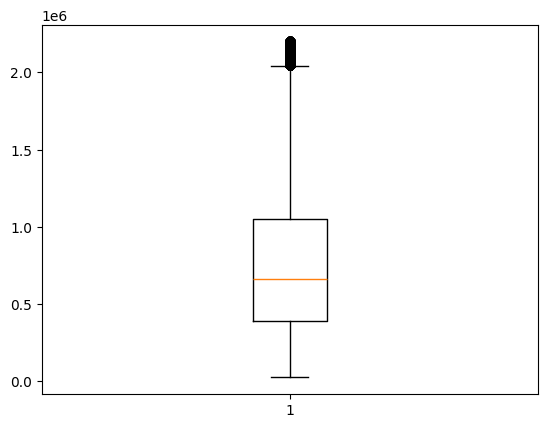

In [45]:
import matplotlib.pyplot as plt
plt.boxplot(df6["fiyat"])

In [46]:
df6[df6["fiyat"] < 200000].shape

(8726, 27)

In [47]:
df6.shape

(163729, 27)

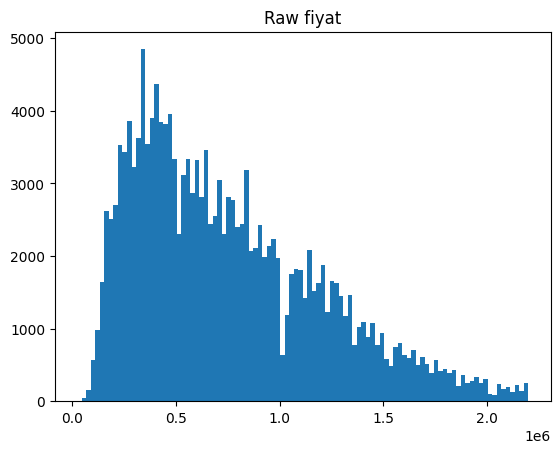

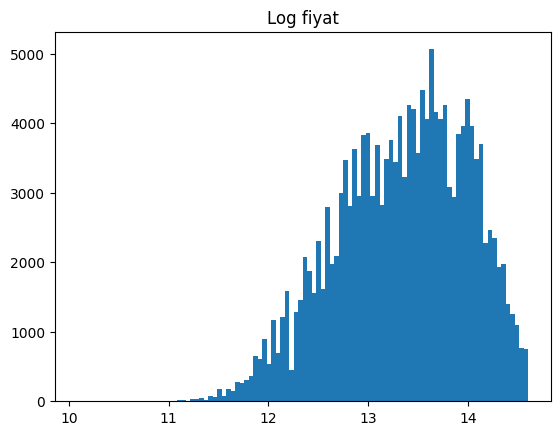

In [48]:

plt.hist(df6["fiyat"], bins=100)
plt.title("Raw fiyat")
plt.show()

plt.hist(np.log1p(df6["fiyat"]), bins=100)
plt.title("Log fiyat")
plt.show()

In [49]:
q1 = df6["fiyat"].quantile(0.25)
q3 = df6["fiyat"].quantile(0.75)
iqr = q3 - q1

alt = q1 - 1.5 * iqr
ust = q3 + 1.5 * iqr

print(alt, ust)

-600000.0 2040000.0


In [50]:
df6[(df6["fiyat"] < alt) | (df6["fiyat"] > ust)].shape

(1363, 27)

In [51]:
df_100_alt = df6[df6["fiyat"]<100000]
df_100_alt.shape

(395, 27)

In [52]:
# IQR sınırları dışındaki 89 aracı veriden çıkar
df_temiz = df6[(df6["fiyat"] >= alt) & (df6["fiyat"] <= ust)].copy()

# Mantıksız derecede ucuz (örn: 100.000 TL altı) hatalı ilanları filtrele
df_temiz = df_temiz[df_temiz["fiyat"] > 100000]

In [53]:
# --- C# ENUM UYUMLAŞTIRMA (VERİ HARMONİZASYONU) ---

# 1. Çekiş Türü
cekis_map = {
    "Önden Çekiş": "ÖndenÇekiş",
    "Arkadan İtiş": "Arkadanİtiş",
    "4WD (Sürekli)": "DörtÇeker",
    "AWD (Elektronik)": "DörtÇeker"
}
df_temiz['cekis'] = df_temiz['cekis'].replace(cekis_map)

# 2. Yakıt Tipi
yakit_map = {
    "LPG & Benzin": "Benzin_LPG"
}
df_temiz['yakit_tipi'] = df_temiz['yakit_tipi'].replace(yakit_map)

# 3. Kasa Tipi
kasa_map = {
    "Hatchback/5": "Hatchback",
    "Hatchback/3": "Hatchback",
    "Station Wagon": "StationWagon",
    "Panelvan": "Van",
    "Roadster": "Cabrio" 
}
df_temiz['kasa_tipi'] = df_temiz['kasa_tipi'].replace(kasa_map)

# 4. Vites Tipi
vites_map = {
    "Yarı Otomatik": "YariOtomatik"
}
df_temiz['vites_tipi'] = df_temiz['vites_tipi'].replace(vites_map)

# 5. Boya ve Değişen Paneller (PanelStatus)
boya_map = {
    "Boyanmış": "Boyali",
    "Lokal Boyanmış": "Boyali",
    "Belirtilmemiş": "Orijinal"  # C# tarafında boş olunca varsayılan olarak Orijinal gidiyor
}

boya_sutunlari = [
    'sag_arka_camurluk', 'arka_kaput', 'sol_arka_camurluk',
    'sag_arka_kapi', 'sag_on_kapi', 'tavan', 'sol_arka_kapi', 'sol_on_kapi',
    'sag_on_camurluk', 'motor_kaputu', 'sol_on_camurluk', 'on_tampon', 'arka_tampon'
]

for col in boya_sutunlari:
    df_temiz[col] = df_temiz[col].replace(boya_map)

In [54]:
df_temiz.head(1)

,fiyat,model,yil,km,vites_tipi,yakit_tipi,kasa_tipi,motor_hacmi,motor_gucu,cekis,...,sol_on_kapi,sag_on_camurluk,motor_kaputu,sol_on_camurluk,on_tampon,arka_tampon,hasar_skoru,degisim_skoru,marka_seri,agir_hasarli_binary
180436,125000.0,Diger,1996.0,290000.0,Düz,Benzin_LPG,Hatchback,1596.0,103.0,ÖndenÇekiş,...,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,Orijinal,2,0,Alfa Romeo_146,0


In [55]:
df_temiz.columns

Index(['fiyat', 'model', 'yil', 'km', 'vites_tipi', 'yakit_tipi', 'kasa_tipi',
       'motor_hacmi', 'motor_gucu', 'cekis', 'sag_arka_camurluk', 'arka_kaput',
       'sol_arka_camurluk', 'sag_arka_kapi', 'sag_on_kapi', 'tavan',
       'sol_arka_kapi', 'sol_on_kapi', 'sag_on_camurluk', 'motor_kaputu',
       'sol_on_camurluk', 'on_tampon', 'arka_tampon', 'hasar_skoru',
       'degisim_skoru', 'marka_seri', 'agir_hasarli_binary'],
      dtype='str')

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

df_final = df_temiz.copy()

df_final = df_final.dropna(subset=['fiyat'])

X = df_final.drop('fiyat', axis=1)
y = df_final['fiyat']

# Veri setini eğitim (%80) ve test (%20) olarak böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Toplam veri sayısı : {len(X)}")
print(f"X_train boyutu     : {X_train.shape}")
print(f"y_train boyutu     : {y_train.shape}")
print(f"X_test  boyutu     : {X_test.shape}")
print(f"y_test  boyutu     : {y_test.shape}")


Toplam veri sayısı : 161840
X_train boyutu     : (129472, 26)
y_train boyutu     : (129472,)
X_test  boyutu     : (32368, 26)
y_test  boyutu     : (32368,)


In [57]:
sayisal_sutunlar = [
    "yil", "km", "motor_hacmi", "motor_gucu",
    "hasar_skoru", "degisim_skoru", "agir_hasarli_binary"
]

kartegorik_sutunlar = [
    "marka_seri", "model", "vites_tipi", "yakit_tipi", "kasa_tipi", 
    "cekis","sag_arka_camurluk", "arka_kaput", "sol_arka_camurluk", 
    "sag_arka_kapi", "sag_on_kapi", "tavan", 
    "sol_arka_kapi", "sol_on_kapi", "sag_on_camurluk", 
    "motor_kaputu", "sol_on_camurluk", "on_tampon", "arka_tampon"
]

In [58]:
# Öncesinde X_train ve y_train'in tanımlandığından emin olun
print(f"X_train boyutu: {X_train.shape}")
print(f"y_train boyutu: {y_train.shape}")
print(f"X_test boyutu: {X_test.shape}")
print(f"y_test boyutu: {y_test.shape}")

# Sütunların doğru olduğunu kontrol edin
print("\nSayısal sütunlar:", sayisal_sutunlar)
print("Kategorik sütunlar:", kartegorik_sutunlar)

# Eksik değer kontrolü
print(f"\nX_train'de eksik değer: {X_train.isnull().sum().sum()}")

X_train boyutu: (129472, 26)
y_train boyutu: (129472,)
X_test boyutu: (32368, 26)
y_test boyutu: (32368,)

Sayısal sütunlar: ['yil', 'km', 'motor_hacmi', 'motor_gucu', 'hasar_skoru', 'degisim_skoru', 'agir_hasarli_binary']
Kategorik sütunlar: ['marka_seri', 'model', 'vites_tipi', 'yakit_tipi', 'kasa_tipi', 'cekis', 'sag_arka_camurluk', 'arka_kaput', 'sol_arka_camurluk', 'sag_arka_kapi', 'sag_on_kapi', 'tavan', 'sol_arka_kapi', 'sol_on_kapi', 'sag_on_camurluk', 'motor_kaputu', 'sol_on_camurluk', 'on_tampon', 'arka_tampon']

X_train'de eksik değer: 0


In [59]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 129472 entries, 162865 to 43587
Data columns (total 26 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   model                129472 non-null  str    
 1   yil                  129472 non-null  float64
 2   km                   129472 non-null  float64
 3   vites_tipi           129472 non-null  str    
 4   yakit_tipi           129472 non-null  str    
 5   kasa_tipi            129472 non-null  str    
 6   motor_hacmi          129472 non-null  float64
 7   motor_gucu           129472 non-null  float64
 8   cekis                129472 non-null  str    
 9   sag_arka_camurluk    129472 non-null  str    
 10  arka_kaput           129472 non-null  str    
 11  sol_arka_camurluk    129472 non-null  str    
 12  sag_arka_kapi        129472 non-null  str    
 13  sag_on_kapi          129472 non-null  str    
 14  tavan                129472 non-null  str    
 15  sol_arka_kapi        129472 n

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Ön İşleme (Preprocessing) Tanımlama
# Sayısal veriler için Standardizasyon, Kategorikler için One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), sayisal_sutunlar),
        ('cat', OneHotEncoder(handle_unknown='ignore'), kartegorik_sutunlar)
    ])

# 2. Pipeline Oluşturma (Önce işlemleri yap, sonra modeli eğit)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 3. Modeli Eğitme
# Not: X_train ve y_train'i bir önceki hücrede oluşturduğunu varsayıyorum
print("Model eğitiliyor... ")
model_pipeline.fit(X_train, y_train)

# 4. Tahmin Yapma ve Başarı Ölçme
y_pred = model_pipeline.predict(X_test)

print(f"R2 Skoru: {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Hata Payı): {mean_absolute_error(y_test, y_pred):.2f} TL")

Model eğitiliyor... 
R2 Skoru: 0.9643
MAE (Hata Payı): 56415.15 TL


In [61]:
import pickle

with open('araba_modeli.pkl', 'wb') as dosya:
    pickle.dump(model_pipeline, dosya)

print("Model başarıyla kaydedildi!")

Model başarıyla kaydedildi!
